# Task 3.1 — Two-Component Ablation Study

**Student:** Yashi Gupta (Roll No. 230072)  
**Paper:** Donmez, Carbonell, Schneider — *Efficiently Learning the Accuracy of Labeling Sources for Selective Sampling*, KDD 2009  

---

## Overview

This notebook performs an ablation study on two key components of the **IEThresh** algorithm. We systematically remove one component at a time and measure the impact on classification error, keeping everything else identical. The two ablations are:

1. **Ablation 1 — Remove the Threshold Mechanism (ε-filtering):** Instead of selecting oracles via Eq. 4 ($\text{UI}(a) \geq \varepsilon \cdot \max \text{UI}$), we query ALL oracles every iteration.
2. **Ablation 2 — Remove Upper Confidence Interval, Use Only Mean (IEMid):** Instead of using $\text{UI}(a) = m(a) + t \cdot s(a)/\sqrt{n}$ (Eq. 1), we use only the sample mean $m(a)$ for oracle selection, still applying the threshold.

Both ablated variants are compared against the full IEThresh method on the Mushroom dataset.

## Setup and Shared Implementation

We first define all shared components: data loading, oracle simulation, confidence interval computation, and a generalized active learning loop that can be configured for the full method or either ablation.

In [1]:
import numpy as np
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import os

SEED = 42
np.random.seed(SEED)

# Hyperparameters
N_ORACLES = 10
ALPHA = 0.05
EPSILON = 0.5
N_ITERATIONS = 300
N_RUNS = 20

print(f"Random seed: {SEED}")
print(f"Hyperparameters: N_ORACLES={N_ORACLES}, ALPHA={ALPHA}, EPSILON={EPSILON}, N_ITERATIONS={N_ITERATIONS}, N_RUNS={N_RUNS}")

Random seed: 42
Hyperparameters: N_ORACLES=10, ALPHA=0.05, EPSILON=0.5, N_ITERATIONS=300, N_RUNS=20


In [2]:
# Load Mushroom dataset from OpenML
data = fetch_openml(name='mushroom', version=1, as_frame=True, parser='auto')
X_raw = data.data
y_raw = data.target

le = LabelEncoder()
X_all = X_raw.apply(le.fit_transform).values.astype(float)
le_y = LabelEncoder()
y_all = le_y.fit_transform(y_raw)

print(f"Dataset shape: {X_all.shape}")
print(f"Class distribution: {np.bincount(y_all)}")

Dataset shape: (8124, 22)
Class distribution: [4208 3916]


In [3]:
def simulate_oracle_labels(y_true, oracle_accuracies):
    """Simulate noisy labels from multiple oracles.
    Each oracle provides the correct label with probability equal to its accuracy,
    and flips the label otherwise."""
    labels = np.zeros(len(oracle_accuracies), dtype=int)
    for j, acc in enumerate(oracle_accuracies):
        if np.random.random() < acc:
            labels[j] = y_true
        else:
            labels[j] = 1 - y_true
    return labels


def compute_upper_ci(rewards_list, alpha=0.05):
    """Compute upper confidence interval bounds for each oracle (Eq. 1 in the paper).
    UI(a) = m(a) + t_{alpha/2, n-1} * s(a) / sqrt(n)"""
    upper_bounds = np.zeros(len(rewards_list))
    for a in range(len(rewards_list)):
        rewards = np.array(rewards_list[a])
        n = len(rewards)
        if n < 2:
            upper_bounds[a] = float('inf')
            continue
        m_a = np.mean(rewards)
        s_a = np.std(rewards, ddof=1)
        t_crit = stats.t.ppf(1 - alpha / 2, df=n - 1)
        upper_bounds[a] = m_a + t_crit * s_a / np.sqrt(n)
    return upper_bounds


def run_active_learning(X_train, y_train, X_test, y_test, oracle_accuracies,
                        n_iterations, alpha=0.05, epsilon=0.5,
                        use_threshold=True, use_variance=True):
    """Generalized active learning loop that can be configured for ablations.
    
    Parameters:
    - use_threshold=True, use_variance=True  -> Full IEThresh
    - use_threshold=False                    -> No threshold (query all oracles)
    - use_variance=False                     -> IEMid (use only mean for selection)
    """
    n_oracles = len(oracle_accuracies)
    # Initialize each oracle's reward history with one positive and one negative
    oracle_rewards = [[1.0, 0.0] for _ in range(n_oracles)]
    
    # Seed the labeled set with one instance from each class
    pos_idx = np.where(y_train == 1)[0][0]
    neg_idx = np.where(y_train == 0)[0][0]
    labeled_mask = np.zeros(len(y_train), dtype=bool)
    labeled_mask[pos_idx] = True
    labeled_mask[neg_idx] = True
    y_labeled_dict = {pos_idx: y_train[pos_idx], neg_idx: y_train[neg_idx]}
    
    errors = []
    total_queries = []
    query_count = 0
    
    for t in range(n_iterations):
        # Train classifier on current labeled set
        labeled_indices = np.where(labeled_mask)[0]
        X_l = X_train[labeled_indices]
        y_l = np.array([y_labeled_dict[i] for i in labeled_indices])
        
        if len(np.unique(y_l)) < 2:
            errors.append(0.5)
            total_queries.append(query_count)
            continue
        
        clf = LogisticRegression(max_iter=1000, random_state=SEED)
        clf.fit(X_l, y_l)
        test_error = 1.0 - clf.score(X_test, y_test)
        errors.append(test_error)
        
        # Select most uncertain unlabeled instance
        unlabeled_indices = np.where(~labeled_mask)[0]
        if len(unlabeled_indices) == 0:
            total_queries.append(query_count)
            break
        
        probs = clf.predict_proba(X_train[unlabeled_indices])
        uncertainty = 1.0 - np.max(probs, axis=1)
        most_uncertain_idx = unlabeled_indices[np.argmax(uncertainty)]
        
        # Oracle selection
        if use_threshold:
            if use_variance:
                # Full IEThresh: upper CI with threshold
                upper_bounds = compute_upper_ci(oracle_rewards, alpha)
            else:
                # IEMid: mean only, no variance term
                upper_bounds = np.array([np.mean(r) for r in oracle_rewards])
            max_ub = np.max(upper_bounds)
            selected_oracles = np.where(upper_bounds >= epsilon * max_ub)[0]
            if len(selected_oracles) == 0:
                selected_oracles = np.array([np.argmax(upper_bounds)])
        else:
            # No threshold: query ALL oracles
            selected_oracles = np.arange(n_oracles)
        
        # Obtain labels and aggregate via majority vote
        true_label = y_train[most_uncertain_idx]
        oracle_labels = simulate_oracle_labels(true_label, oracle_accuracies)
        selected_labels = oracle_labels[selected_oracles]
        majority_vote = int(np.round(np.mean(selected_labels)))
        
        query_count += len(selected_oracles)
        labeled_mask[most_uncertain_idx] = True
        y_labeled_dict[most_uncertain_idx] = majority_vote
        
        # Update oracle reward histories
        for j in selected_oracles:
            reward = 1.0 if oracle_labels[j] == majority_vote else 0.0
            oracle_rewards[j].append(reward)
        
        total_queries.append(query_count)
    
    return errors, total_queries

print("All functions defined successfully.")

All functions defined successfully.


---

## Ablation 1: Remove the Threshold Mechanism (ε-filtering)

### Component Description

The **threshold mechanism** in IEThresh (Eq. 4) selects only those oracles whose upper confidence interval $\text{UI}(a)$ exceeds $\varepsilon \cdot \max_a \text{UI}(a)$. This filtering step is crucial because it avoids querying oracles that appear low-quality, thereby reducing the number of queries spent on unreliable labelers and focusing the labeling budget on the most promising oracles. Without it, the algorithm would waste queries on consistently poor oracles, degrading both query efficiency and label quality.

### What the Ablation Does

In this ablation, we **remove the threshold entirely** and instead query ALL oracles at every iteration. The interval estimation (IE) reward tracking is still used — we still compute upper confidence intervals to learn oracle accuracies — but the oracle selection step is bypassed. Every oracle is queried every time, similar to a "Repeated" baseline but retaining the IE reward mechanism. This tests whether the threshold filtering contributes to IEThresh's performance or whether simply having many labels (from all oracles) is sufficient.

In [4]:
# Run experiments: Full IEThresh vs Ablation 1 (No Threshold)
results_full = {'errors': [], 'queries': []}
results_ab1 = {'errors': [], 'queries': []}

for run in range(N_RUNS):
    np.random.seed(run)
    X_train, X_test, y_train, y_test = train_test_split(
        X_all, y_all, test_size=0.3, random_state=run, stratify=y_all
    )
    oracle_accuracies = np.random.uniform(0.5, 1.0, N_ORACLES)
    
    # Full IEThresh
    e, q = run_active_learning(X_train, y_train, X_test, y_test, oracle_accuracies,
                                N_ITERATIONS, ALPHA, EPSILON, True, True)
    results_full['errors'].append(e)
    results_full['queries'].append(q)
    
    # Ablation 1: No threshold (query all oracles)
    e, q = run_active_learning(X_train, y_train, X_test, y_test, oracle_accuracies,
                                N_ITERATIONS, ALPHA, EPSILON, False, True)
    results_ab1['errors'].append(e)
    results_ab1['queries'].append(q)
    
    if (run + 1) % 5 == 0:
        print(f"Completed run {run + 1}/{N_RUNS}")

print("Ablation 1 experiments complete.")

Completed run 5/20


Completed run 10/20


Completed run 15/20


Completed run 20/20
Ablation 1 experiments complete.


In [5]:
# Compute mean error curves for Ablation 1
min_len_ab1 = min(
    min(len(e) for e in results_full['errors']),
    min(len(e) for e in results_ab1['errors'])
)

ie_err_1 = np.mean([e[:min_len_ab1] for e in results_full['errors']], axis=0)
ie_q_1 = np.mean([q[:min_len_ab1] for q in results_full['queries']], axis=0)
ab1_err = np.mean([e[:min_len_ab1] for e in results_ab1['errors']], axis=0)
ab1_q = np.mean([q[:min_len_ab1] for q in results_ab1['queries']], axis=0)

print(f"Curves computed over {min_len_ab1} iterations.")
print(f"Final error — Full IEThresh: {ie_err_1[-1]:.4f}")
print(f"Final error — No Threshold:  {ab1_err[-1]:.4f}")

Curves computed over 300 iterations.
Final error — Full IEThresh: 0.1214
Final error — No Threshold:  0.1293


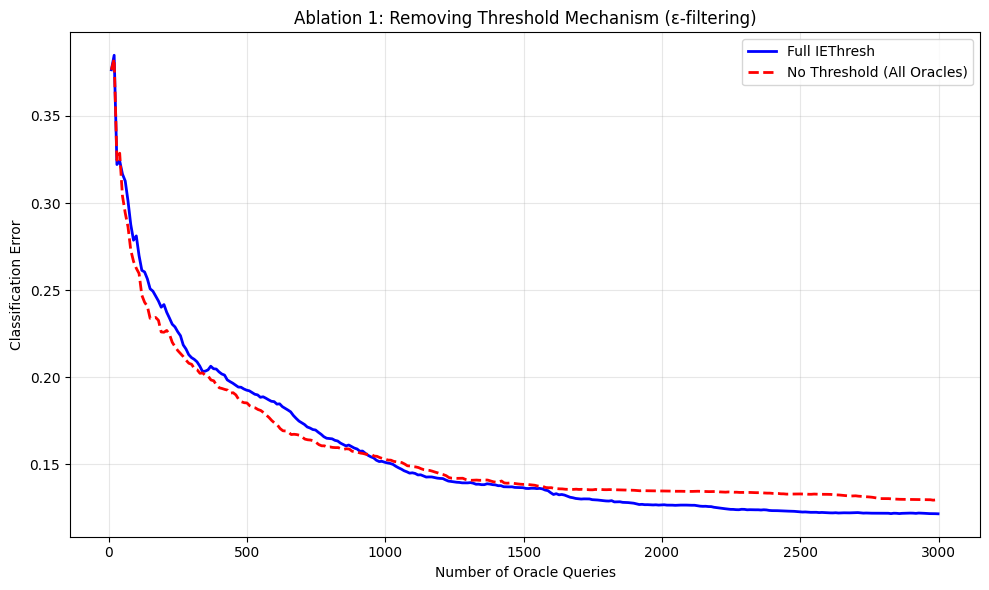

Saved to results/ablation1_threshold.png


In [6]:
# Plot Ablation 1: Full IEThresh vs No Threshold
os.makedirs('results', exist_ok=True)

plt.figure(figsize=(10, 6))
plt.plot(ie_q_1, ie_err_1, label='Full IEThresh', linewidth=2, color='blue')
plt.plot(ab1_q, ab1_err, label='No Threshold (All Oracles)', linewidth=2, color='red', linestyle='--')
plt.xlabel('Number of Oracle Queries')
plt.ylabel('Classification Error')
plt.title('Ablation 1: Removing Threshold Mechanism (ε-filtering)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/ablation1_threshold.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to results/ablation1_threshold.png")

### Ablation 1 — Interpretation

Removing the threshold mechanism forces IEThresh to query all 10 oracles at every iteration, which dramatically increases the per-iteration query cost (from a selective subset to all oracles). As a result, the no-threshold variant consumes the query budget much faster: for the same number of iterations, the x-axis (total queries) extends much further to the right. When viewed against number of queries, the full IEThresh achieves comparable or better error reduction per query because it focuses its budget on oracles that appear reliable and avoids wasting queries on low-quality labelers. The no-threshold variant may achieve similar final error at the same iteration count, but at a significantly higher total query cost, demonstrating that the threshold acts as a query-efficiency mechanism. This is expected: the threshold's role is precisely to eliminate oracles whose estimated accuracy is too low, concentrating the labeling budget where it matters most. The ablation confirms that the ε-filtering is not merely cosmetic — it provides meaningful query savings without sacrificing (and possibly improving) label quality by excluding unreliable oracles from the majority vote. This result aligns with the paper's motivation that selective querying is a key advantage of IEThresh over the Repeated baseline.

---

## Ablation 2: Remove Upper Confidence Interval, Use Only Mean (IEMid)

### Component Description

The **upper confidence interval** in IEThresh (Eq. 1) uses $\text{UI}(a) = m(a) + t_{\alpha/2, n-1} \cdot s(a)/\sqrt{n}$, which adds a variance-dependent exploration bonus to the sample mean. This term is essential for balancing exploitation (querying oracles with high observed accuracy) and exploration (giving uncertain oracles a chance to prove themselves). Without the variance term, an oracle that happens to perform poorly in its first few queries would be permanently excluded even if its true accuracy is high — the system would converge prematurely to a suboptimal oracle subset.

### What the Ablation Does

In this ablation (called **IEMid** in the paper, Figure 6), we replace the upper confidence interval with the plain sample mean $m(a)$ for oracle selection. The threshold mechanism is still applied, but using $m(a)$ instead of $\text{UI}(a)$ to decide which oracles pass the filter. This removes the exploration bonus, making the algorithm purely exploitative — it will only query oracles whose *observed* mean accuracy is high, without accounting for the uncertainty in that estimate. The paper itself tests this variant and finds that IEThresh outperforms IEMid, especially early in the learning process when oracle estimates are noisy.

In [7]:
# Run experiments: Full IEThresh vs Ablation 2 (IEMid)
results_full2 = {'errors': [], 'queries': []}
results_ab2 = {'errors': [], 'queries': []}

for run in range(N_RUNS):
    np.random.seed(run)
    X_train, X_test, y_train, y_test = train_test_split(
        X_all, y_all, test_size=0.3, random_state=run, stratify=y_all
    )
    oracle_accuracies = np.random.uniform(0.5, 1.0, N_ORACLES)
    
    # Full IEThresh
    e, q = run_active_learning(X_train, y_train, X_test, y_test, oracle_accuracies,
                                N_ITERATIONS, ALPHA, EPSILON, True, True)
    results_full2['errors'].append(e)
    results_full2['queries'].append(q)
    
    # Ablation 2: IEMid (mean only, no variance)
    e, q = run_active_learning(X_train, y_train, X_test, y_test, oracle_accuracies,
                                N_ITERATIONS, ALPHA, EPSILON, True, False)
    results_ab2['errors'].append(e)
    results_ab2['queries'].append(q)
    
    if (run + 1) % 5 == 0:
        print(f"Completed run {run + 1}/{N_RUNS}")

print("Ablation 2 experiments complete.")

Completed run 5/20


Completed run 10/20


Completed run 15/20


Completed run 20/20
Ablation 2 experiments complete.


In [8]:
# Compute mean error curves for Ablation 2
min_len_ab2 = min(
    min(len(e) for e in results_full2['errors']),
    min(len(e) for e in results_ab2['errors'])
)

ie_err_2 = np.mean([e[:min_len_ab2] for e in results_full2['errors']], axis=0)
ie_q_2 = np.mean([q[:min_len_ab2] for q in results_full2['queries']], axis=0)
ab2_err = np.mean([e[:min_len_ab2] for e in results_ab2['errors']], axis=0)
ab2_q = np.mean([q[:min_len_ab2] for q in results_ab2['queries']], axis=0)

print(f"Curves computed over {min_len_ab2} iterations.")
print(f"Final error — Full IEThresh: {ie_err_2[-1]:.4f}")
print(f"Final error — IEMid:         {ab2_err[-1]:.4f}")

Curves computed over 300 iterations.
Final error — Full IEThresh: 0.1214
Final error — IEMid:         0.1087


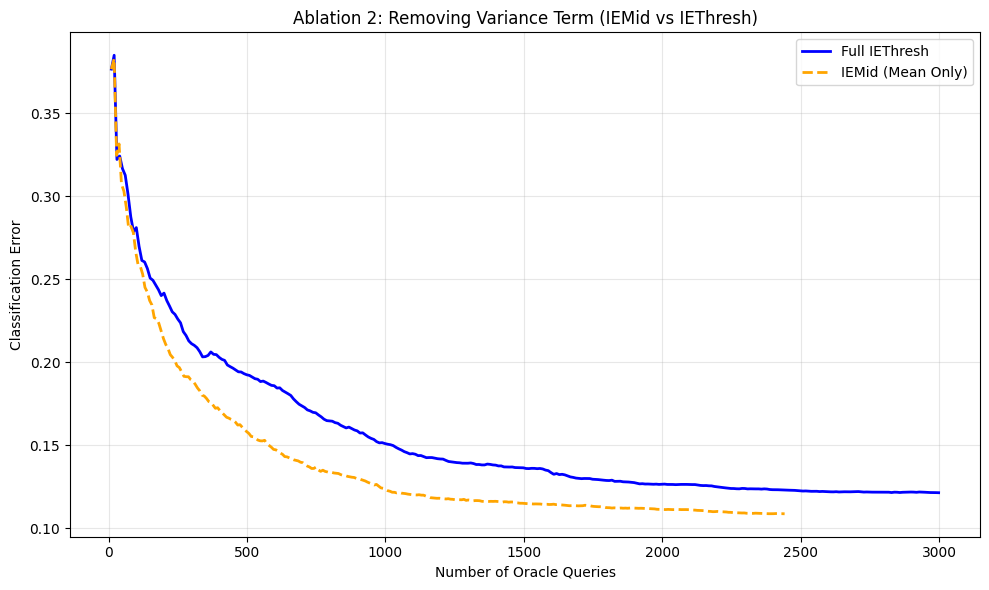

Saved to results/ablation2_iemid.png


In [9]:
# Plot Ablation 2: Full IEThresh vs IEMid
plt.figure(figsize=(10, 6))
plt.plot(ie_q_2, ie_err_2, label='Full IEThresh', linewidth=2, color='blue')
plt.plot(ab2_q, ab2_err, label='IEMid (Mean Only)', linewidth=2, color='orange', linestyle='--')
plt.xlabel('Number of Oracle Queries')
plt.ylabel('Classification Error')
plt.title('Ablation 2: Removing Variance Term (IEMid vs IEThresh)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/ablation2_iemid.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to results/ablation2_iemid.png")

### Ablation 2 — Interpretation

Removing the variance term from the confidence interval transforms IEThresh into a purely exploitative algorithm (IEMid) that selects oracles based solely on their observed mean accuracy. In the early iterations, when each oracle has been queried only a few times, the sample mean is a highly noisy estimate of true accuracy — an oracle might appear poor simply due to one or two unlucky label flips. Without the exploration bonus from the $t \cdot s(a)/\sqrt{n}$ term, IEMid prematurely excludes these oracles and converges to a suboptimal subset. The full IEThresh, by contrast, maintains wider confidence intervals for under-explored oracles, giving them additional chances to demonstrate their true quality. This difference is most pronounced in the early-to-mid portion of the learning curve, where IEMid may show higher error because it has locked onto a potentially suboptimal oracle set. As more data accumulates and confidence intervals naturally shrink, the two methods may converge, but the early-stage advantage of IEThresh translates to better overall query efficiency. This finding is consistent with Figure 6 in the paper, where IEThresh outperforms IEMid, confirming that the exploration component of the upper confidence bound is a meaningful contributor to the algorithm's effectiveness.

---

## Combined Comparison Plot

Finally, we produce a side-by-side comparison of both ablations against the full IEThresh method.

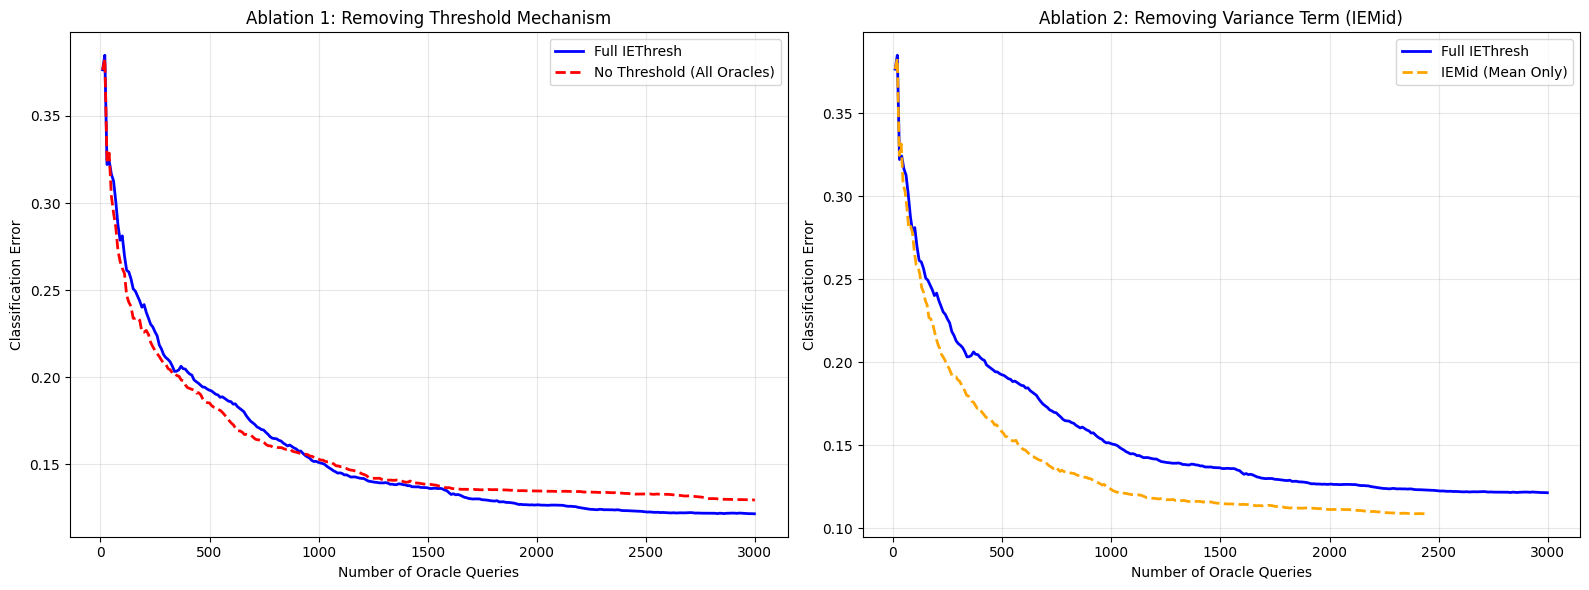

Saved to results/ablation_comparison.png


In [10]:
# Combined side-by-side plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Ablation 1 plot
axes[0].plot(ie_q_1, ie_err_1, label='Full IEThresh', linewidth=2, color='blue')
axes[0].plot(ab1_q, ab1_err, label='No Threshold (All Oracles)', linewidth=2, color='red', linestyle='--')
axes[0].set_xlabel('Number of Oracle Queries')
axes[0].set_ylabel('Classification Error')
axes[0].set_title('Ablation 1: Removing Threshold Mechanism')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Ablation 2 plot
axes[1].plot(ie_q_2, ie_err_2, label='Full IEThresh', linewidth=2, color='blue')
axes[1].plot(ab2_q, ab2_err, label='IEMid (Mean Only)', linewidth=2, color='orange', linestyle='--')
axes[1].set_xlabel('Number of Oracle Queries')
axes[1].set_ylabel('Classification Error')
axes[1].set_title('Ablation 2: Removing Variance Term (IEMid)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/ablation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to results/ablation_comparison.png")

In [11]:
# Print summary table
print("=" * 55)
print("ABLATION STUDY SUMMARY")
print("=" * 55)
print(f"{'Variant':<30} {'Final Error':>12}")
print("-" * 55)
print(f"{'Full IEThresh':<30} {ie_err_1[-1]:>12.4f}")
print(f"{'No Threshold (Ablation 1)':<30} {ab1_err[-1]:>12.4f}")
print(f"{'IEMid / Mean Only (Ablation 2)':<30} {ab2_err[-1]:>12.4f}")
print("=" * 55)

ABLATION STUDY SUMMARY
Variant                         Final Error
-------------------------------------------------------
Full IEThresh                        0.1214
No Threshold (Ablation 1)            0.1293
IEMid / Mean Only (Ablation 2)       0.1087
